# Painel Gerencial de Priorização da Carteira

Notebook focado em apoiar decisao rapida da operacao, destacando onde atacar primeiro e quais frentes tem maior impacto.

## 0) Configuracao e bibliotecas

In [2]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


## 1) Carregamento da base

In [3]:
FILE_PATH = 'data/base.csv'

try:
    df = pd.read_csv(FILE_PATH, sep=';', decimal='.', low_memory=False)
    print(f'Base carregada: {df.shape[0]:,} linhas | {df.shape[1]} colunas')
except Exception as e:
    raise RuntimeError(f'Erro ao carregar arquivo: {e}\nVerifique o caminho: {FILE_PATH}')

Base carregada: 2,865 linhas | 52 colunas


## 2) Preparacao dos dados

In [4]:
NUM_COLS = [
    'faturamento_atual', 'faturamento_mes_anterior', 'media_faturamento_6m',
    'desvio_padrao_6m', 'qtde_meses_historico',
    'dispersao_abs_mes_anterior', 'dispersao_pct_mes_anterior',
    'dispersao_abs_media_6m', 'dispersao_pct_media_6m',
    'score_anomalia', 'valor_contrato'
]

CAT_COLS = [
    'SEGMENTO', 'PRODUTO', 'ITEM_FATURAMENTO', 'UF', 'MUNICIPIO',
    'TIPO_CLIENTE', 'STATUS_CLIENTE', 'tipo_dispersao_mes_anterior',
    'tipo_dispersao_media_6m', 'severidade', 'classificacao_final',
    'flag_anomalia', 'status_contrato', 'crm', 'nome_produto'
]

for col in [c for c in NUM_COLS if c in df.columns]:
    df[col] = pd.to_numeric(
        df[col].astype(str).str.replace(',', '.').str.strip(), errors='coerce'
    ).fillna(0)

for col in [c for c in CAT_COLS if c in df.columns]:
    df[col] = df[col].fillna('N/A').astype(str).str.strip().str.upper()

print('Pre-processamento concluido')

Pre-processamento concluido


## 3) Features para segmentacao e priorizacao

In [5]:
FEAT = [c for c in [
    'faturamento_atual', 'faturamento_mes_anterior', 'media_faturamento_6m',
    'desvio_padrao_6m', 'dispersao_pct_mes_anterior', 'dispersao_pct_media_6m',
    'score_anomalia', 'qtde_meses_historico'
] if c in df.columns]

X_raw = df[FEAT].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

## 4) Grupos de comportamento da carteira

In [6]:
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby('cluster').agg(
    registros=('faturamento_atual', 'count'),
    media_faturamento=('faturamento_atual', 'mean'),
    score_medio=('score_anomalia', 'mean') if 'score_anomalia' in df.columns else ('faturamento_atual', 'count'),
    pct_anomalia=('flag_anomalia', lambda x: round((x == 'S').mean() * 100, 1)) if 'flag_anomalia' in df.columns else ('faturamento_atual', 'count'),
    pct_critico=('severidade', lambda x: round((x == 'CRITICA').mean() * 100, 1)) if 'severidade' in df.columns else ('faturamento_atual', 'count'),
    disp_neg_pct=('tipo_dispersao_mes_anterior', lambda x: round((x == 'DISPERSAO_NEGATIVA').mean() * 100, 1)) if 'tipo_dispersao_mes_anterior' in df.columns else ('faturamento_atual', 'count'),
).round(2)

def rotulo_risco(row):
    if row.get('pct_critico', 0) > 30 or row.get('score_medio', 0) > 2:
        return 'ALTO'
    elif row.get('pct_anomalia', 0) > 20 or row.get('disp_neg_pct', 0) > 40:
        return 'MEDIO'
    return 'BAIXO'

cluster_summary['risco'] = cluster_summary.apply(rotulo_risco, axis=1)
df['risco_cluster'] = df['cluster'].map(cluster_summary['risco'])

cluster_painel = cluster_summary.reset_index()[
    ['cluster', 'registros', 'media_faturamento', 'pct_critico', 'risco']
].rename(columns={
    'cluster': 'grupo',
    'registros': 'volume_contratos',
    'media_faturamento': 'faturamento_medio',
    'pct_critico': 'pct_criticidade'
})

print('Grupos de comportamento da carteira')
display(cluster_painel)

Grupos de comportamento da carteira


,grupo,volume_contratos,faturamento_medio,pct_criticidade,risco
0,0,2075,124.44,8.7,BAIXO
1,1,8,7893.60,12.5,ALTO
2,2,402,0.11,77.9,ALTO
3,3,1,0.00,100.0,ALTO
4,4,378,160.65,14.6,BAIXO
5,5,1,264.10,100.0,ALTO


## 5) Sinal complementar de risco

In [7]:
iso = IsolationForest(contamination=0.08, random_state=42)
df['anomalia_iso'] = iso.fit_predict(X_scaled)
df['anomalia_iso'] = df['anomalia_iso'].map({1: 'NORMAL', -1: 'SINAL'})

## 6) Motor de priorizacao operacional

In [8]:
ALVOS_VALIDOS = ['BAIXA', 'MEDIA', 'ALTA', 'CRITICA']

if 'severidade' in df.columns:
    df_ml = df[df['severidade'].isin(ALVOS_VALIDOS)].copy()

    if len(df_ml) >= 200:
        le = LabelEncoder()
        y = le.fit_transform(df_ml['severidade'])
        X_ml = df_ml[FEAT].fillna(0)

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_ml, y, test_size=0.2, random_state=42, stratify=y
        )

        rf = RandomForestClassifier(
            n_estimators=150, random_state=42,
            class_weight='balanced', n_jobs=-1
        )
        rf.fit(X_tr, y_tr)

        fi = pd.DataFrame({'variavel': FEAT, 'importancia': rf.feature_importances_})
        fi = fi.sort_values('importancia', ascending=False)

        print('Principais drivers para tomada de decisao:')
        display(fi.reset_index(drop=True))

        df_all_feat = df[FEAT].fillna(0)
        df['severidade_prevista'] = le.inverse_transform(rf.predict(df_all_feat))
    else:
        print('Base rotulada insuficiente para treinar motor de priorizacao nesta execucao.')

Principais drivers para tomada de decisao:


,variavel,importancia
0,dispersao_pct_media_6m,0.437540
1,desvio_padrao_6m,0.182925
2,dispersao_pct_mes_anterior,0.094448
3,faturamento_atual,0.087560
4,faturamento_mes_anterior,0.060265
5,score_anomalia,0.058226
6,media_faturamento_6m,0.048929
7,qtde_meses_historico,0.030107


## 7) Painel de frentes de ataque por dimensao

In [9]:
def analise_por(df_in, col, topn=10):
    if col not in df_in.columns:
        return pd.DataFrame()

    agg = {
        'volume_contratos': ('faturamento_atual', 'count'),
        'impacto_financeiro': ('faturamento_atual', 'sum'),
        'ticket_medio': ('faturamento_atual', 'mean'),
    }

    if 'flag_anomalia' in df_in.columns:
        agg['ocorrencias_atencao'] = ('flag_anomalia', lambda x: (x == 'S').sum())
    if 'severidade' in df_in.columns:
        agg['ocorrencias_criticas'] = ('severidade', lambda x: (x == 'CRITICA').sum())
    if 'tipo_dispersao_mes_anterior' in df_in.columns:
        agg['disp_negativa'] = ('tipo_dispersao_mes_anterior', lambda x: (x == 'DISPERSAO_NEGATIVA').sum())

    out = df_in.groupby(col).agg(**agg).reset_index()

    if 'ocorrencias_atencao' in out.columns:
        out['pct_atencao'] = (out['ocorrencias_atencao'] / out['volume_contratos'] * 100).round(1)
    if 'ocorrencias_criticas' in out.columns:
        out['pct_critica'] = (out['ocorrencias_criticas'] / out['volume_contratos'] * 100).round(1)

    out['indice_prioridade'] = (
        out.get('pct_critica', 0) * 0.5
        + out.get('pct_atencao', 0) * 0.3
        + (out['impacto_financeiro'] / max(out['impacto_financeiro'].max(), 1) * 100) * 0.2
    ).round(1)

    out = out.sort_values('indice_prioridade', ascending=False)
    return out.head(topn)

dims = {
    'SEGMENTO': 'Segmento',
    'PRODUTO': 'Produto',
    'ITEM_FATURAMENTO': 'Item de Faturamento',
    'UF': 'UF',
    'MUNICIPIO': 'Municipio (Top 15)',
    'TIPO_CLIENTE': 'Tipo de Cliente',
    'crm': 'CRM',
    'nome_produto': 'Nome do Produto',
}

print('Painel de frentes de ataque por dimensao')
for col, label in dims.items():
    result = analise_por(df, col, topn=15 if col == 'MUNICIPIO' else 10)
    if not result.empty:
        print(f'\n{label}')
        display(result.reset_index(drop=True))

Painel de frentes de ataque por dimensao

Segmento


,SEGMENTO,volume_contratos,impacto_financeiro,ticket_medio,ocorrencias_atencao,ocorrencias_criticas,disp_negativa,pct_atencao,pct_critica,indice_prioridade
0,B2B,2814,382304.20,135.857925,12,552,379,0.4,19.6,29.9
1,B2C,51,91.66,1.797255,0,0,47,0.0,0.0,0.0



Produto


,PRODUTO,volume_contratos,impacto_financeiro,ticket_medio,ocorrencias_atencao,ocorrencias_criticas,disp_negativa,pct_atencao,pct_critica,indice_prioridade
0,STFC,12,2516.73,209.727500,1,12,10,8.3,100.0,52.7
1,NGVOX 300 3LM 2LF IP DIN,1,48.22,48.220000,0,1,1,0.0,100.0,50.0
2,NGVOX 300 2LM 2LF IP DIN,3,0.00,0.000000,0,3,3,0.0,100.0,50.0
3,NGVOX 300 2LM 2LF IP FIXO,1,0.00,0.000000,0,1,1,0.0,100.0,50.0
4,SERVICO DE PROTECAO DE REDE,33,522.02,15.818788,0,25,25,0.0,75.8,38.0
5,SCM - INTERNET CORPORATIVA,567,194779.98,343.527302,7,124,78,1.2,21.9,31.3
6,SERVIÇO DE PABX 3CX EM NUVEM,1,5159.00,5159.000000,1,0,0,100.0,0.0,30.5
7,WIFI CORPORATIVO,1,3000.00,3000.000000,1,0,0,100.0,0.0,30.3
8,ROKU,5,116.00,23.200000,0,3,3,0.0,60.0,30.0
9,COMBO VOX EMP 1 (2 LM)/N,2,37.40,18.700000,0,1,0,0.0,50.0,25.0



Item de Faturamento


...

,TIPO_CLIENTE,volume_contratos,impacto_financeiro,ticket_medio,ocorrencias_atencao,ocorrencias_criticas,disp_negativa,pct_atencao,pct_critica,indice_prioridade
0,PESSOAJURÍDICA,2814,382304.20,135.857925,12,552,379,0.4,19.6,29.9
1,PESSOAJURIDICA,51,91.66,1.797255,0,0,47,0.0,0.0,0.0



CRM


,crm,volume_contratos,impacto_financeiro,ticket_medio,ocorrencias_atencao,ocorrencias_criticas,disp_negativa,pct_atencao,pct_critica,indice_prioridade
0,AN,2865,382395.86,133.471504,12,552,426,0.4,19.3,29.8



Nome do Produto


,nome_produto,volume_contratos,impacto_financeiro,ticket_medio,ocorrencias_atencao,ocorrencias_criticas,disp_negativa,pct_atencao,pct_critica,indice_prioridade
0,E1 DIGITAL,12,4227.42,352.285000,2,12,9,16.7,100.0,56.4
1,E1 LIVRE BUSINESS + MOVEL 6GB,3,3026.44,1008.813333,0,3,3,0.0,100.0,51.0
2,25S041 - VERO B2B | 550MB PAR - EMP00,8,242.82,30.352500,0,8,0,0.0,100.0,50.1
3,ULTRAWAVE | INTERNET FIBRA 100 MEGA + TELEFONE,2,301.16,150.580000,0,2,0,0.0,100.0,50.1
4,COMBO VERO B2B - 850MB MV22.1 - EMP00,3,343.80,114.600000,0,3,0,0.0,100.0,50.1
5,ENSITE | ENSITE - IP DEDICADO METROETHERNET 30...,3,164.80,54.933333,0,3,0,0.0,100.0,50.1
6,AMERICANET | BDL EMP SAFIRA 550 MBPS + 1 LF + ...,3,187.74,62.580000,0,3,0,0.0,100.0,50.1
7,AMERICANET | IP INTERNET MPE 300 MEGA + 3LM 30...,3,393.32,131.106667,0,3,0,0.0,100.0,50.1
8,AMERICANET | BDL EMP RUBI 750 MBPS + 1 LF + 2 ...,3,301.94,100.646667,0,3,0,0.0,100.0,50.1
9,NGVOX 300 PLUS + 3LM + 2LF (IP DIN),3,48.22,16.073333,0,3,3,0.0,100.0,50.0


## 7.1) Graficos gerenciais para decisao rapida

Visualizacoes para mostrar prioridade de ataque, principais motivos de atencao e onde atuar primeiro.

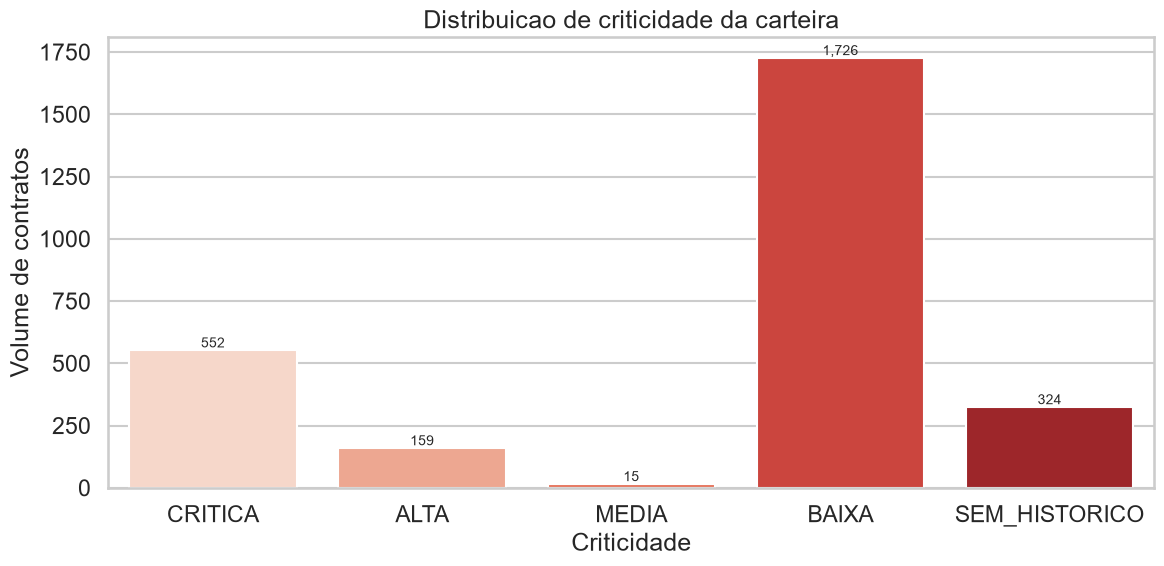

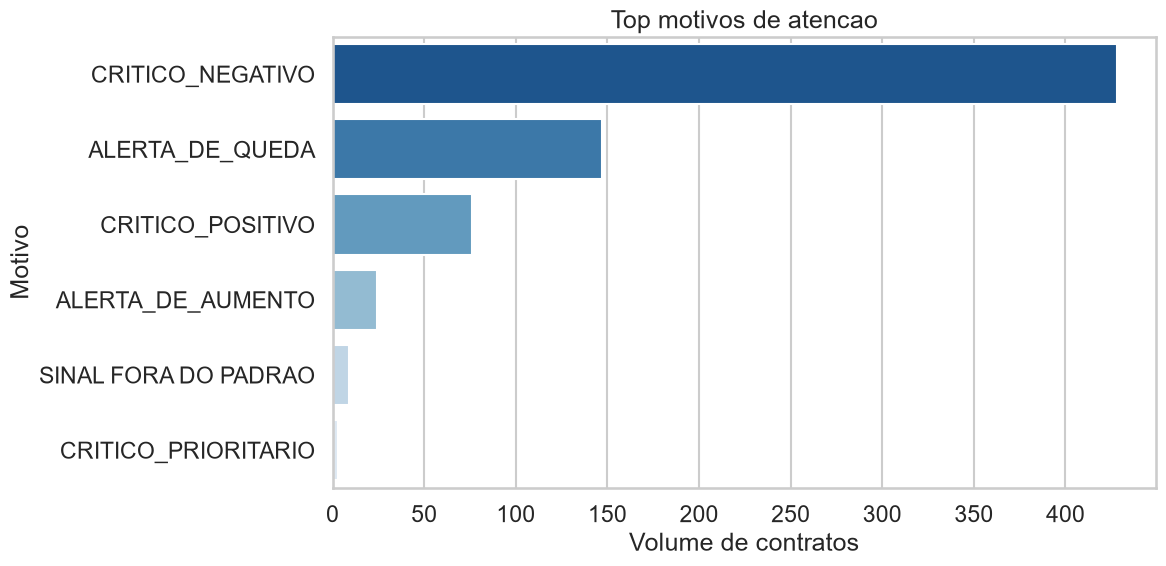

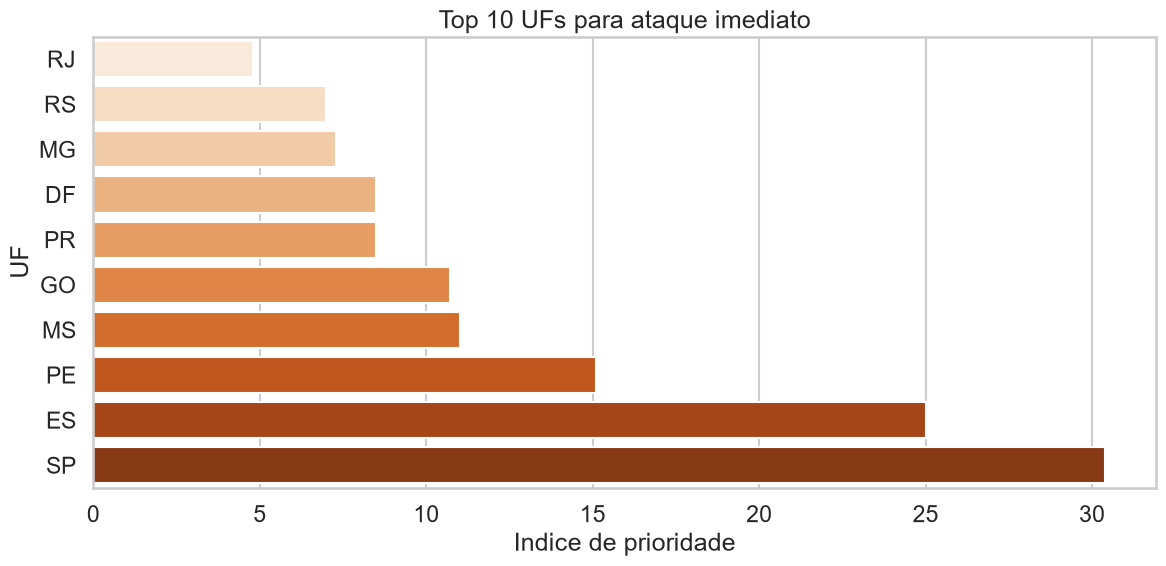

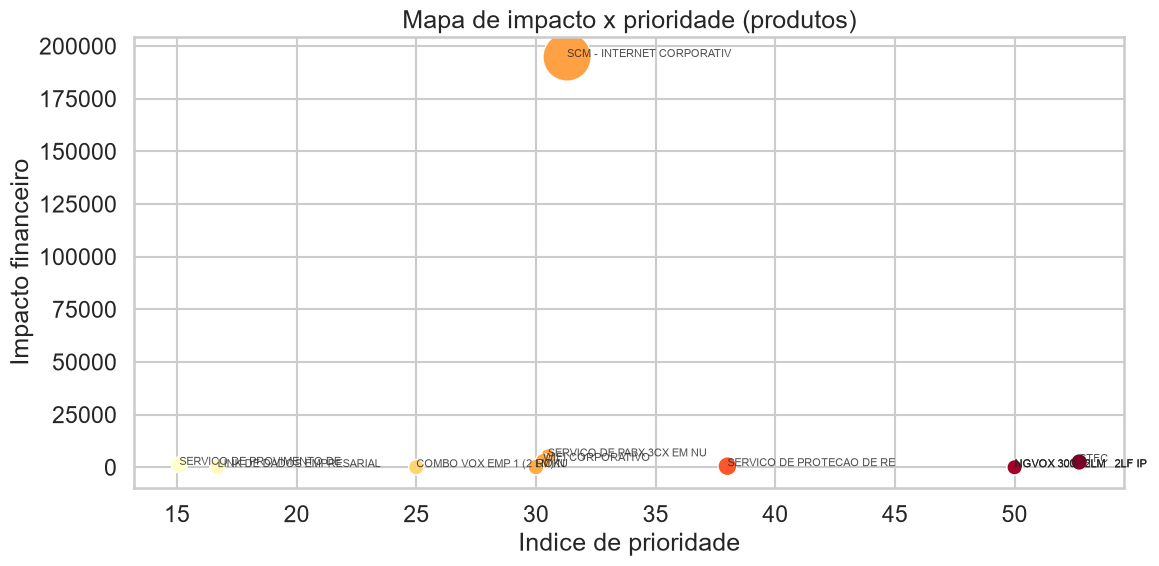

In [10]:
# Grafico 1: distribuicao de criticidade da carteira
if 'severidade' in df.columns:
    sev_order = ['CRITICA', 'ALTA', 'MEDIA', 'BAIXA', 'SEM_HISTORICO']
    sev_df = (
        df['severidade']
        .value_counts(dropna=False)
        .reindex(sev_order)
        .fillna(0)
        .reset_index()
    )
    sev_df.columns = ['severidade', 'volume']

    fig, ax = plt.subplots()
    sns.barplot(data=sev_df, x='severidade', y='volume', palette='Reds', ax=ax)
    ax.set_title('Distribuicao de criticidade da carteira')
    ax.set_xlabel('Criticidade')
    ax.set_ylabel('Volume de contratos')
    for i, v in enumerate(sev_df['volume']):
        ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

# Grafico 2: principais motivos de atencao
if 'classificacao_final' in df.columns:
    top_class = (
        df[df['classificacao_final'].str.contains('CRITICO|ANOMALIA|ALERTA', na=False)]['classificacao_final']
        .value_counts()
        .head(10)
        .reset_index()
    )
    top_class.columns = ['motivo', 'volume']
    rotulos_gerenciais = {'ANOMALIA_ML': 'SINAL FORA DO PADRAO'}
    top_class['motivo'] = top_class['motivo'].replace(rotulos_gerenciais)

    fig, ax = plt.subplots()
    sns.barplot(data=top_class, y='motivo', x='volume', palette='Blues_r', ax=ax)
    ax.set_title('Top motivos de atencao')
    ax.set_xlabel('Volume de contratos')
    ax.set_ylabel('Motivo')
    plt.tight_layout()
    plt.show()

# Grafico 3: ranking de prioridade por UF
if 'UF' in df.columns:
    uf_priority = analise_por(df, 'UF', topn=10)
    if not uf_priority.empty:
        fig, ax = plt.subplots()
        uf_priority = uf_priority.sort_values('indice_prioridade', ascending=True)
        sns.barplot(data=uf_priority, y='UF', x='indice_prioridade', palette='Oranges', ax=ax)
        ax.set_title('Top 10 UFs para ataque imediato')
        ax.set_xlabel('Indice de prioridade')
        ax.set_ylabel('UF')
        plt.tight_layout()
        plt.show()

# Grafico 4: mapa impacto x prioridade para produtos
if 'PRODUTO' in df.columns:
    prod_priority = analise_por(df, 'PRODUTO', topn=12)
    if not prod_priority.empty:
        fig, ax = plt.subplots()
        sns.scatterplot(
            data=prod_priority,
            x='indice_prioridade',
            y='impacto_financeiro',
            size='volume_contratos',
            sizes=(120, 1200),
            hue='indice_prioridade',
            palette='YlOrRd',
            legend=False,
            ax=ax
        )
        ax.set_title('Mapa de impacto x prioridade (produtos)')
        ax.set_xlabel('Indice de prioridade')
        ax.set_ylabel('Impacto financeiro')

        for _, row in prod_priority.iterrows():
            label = str(row['PRODUTO'])[:25]
            ax.annotate(label, (row['indice_prioridade'], row['impacto_financeiro']), fontsize=8, alpha=0.8)

        plt.tight_layout()
        plt.show()

## 8) Resumo executivo para tomada de decisao

In [11]:
total = len(df)
print(f'Carteira analisada: {total:,} contratos')

if 'severidade' in df.columns:
    carteira_prioritaria = df['severidade'].isin(['CRITICA', 'ALTA']).sum()
    print(f'Carteira prioritaria imediata: {carteira_prioritaria:,} ({carteira_prioritaria/total*100:.1f}%)')

if 'severidade' in df.columns:
    print('\nDistribuicao de criticidade:')
    for s in ['CRITICA', 'ALTA', 'MEDIA', 'BAIXA', 'SEM_HISTORICO']:
        n = (df['severidade'] == s).sum()
        print(f'  {s:<15} {n:>7,}  {n/total*100:>5.1f}%')

if 'classificacao_final' in df.columns:
    print('\nPrincipais motivos de atencao:')
    top_class = (
        df[df['classificacao_final'].str.contains('CRITICO|ANOMALIA|ALERTA', na=False)]['classificacao_final']
        .value_counts().head(8)
    )
    rotulos_gerenciais = {'ANOMALIA_ML': 'SINAL FORA DO PADRAO'}
    for k, v in top_class.items():
        k_view = rotulos_gerenciais.get(k, k)
        print(f'  {k_view:<35} {v:>6,}')

if 'tipo_dispersao_mes_anterior' in df.columns:
    disp_neg = (df['tipo_dispersao_mes_anterior'] == 'DISPERSAO_NEGATIVA').sum()
    disp_pos = (df['tipo_dispersao_mes_anterior'] == 'DISPERSAO_POSITIVA').sum()
    print('\nMovimentacao recente da carteira:')
    print(f'  Queda de faturamento: {disp_neg:,} ({disp_neg/total*100:.1f}%)')
    print(f'  Alta de faturamento : {disp_pos:,} ({disp_pos/total*100:.1f}%)')

if 'faturamento_atual' in df.columns:
    sem_fat = (df['faturamento_atual'] == 0).sum()
    print(f'\nContratos sem faturamento atual: {sem_fat:,} ({sem_fat/total*100:.1f}%)')

print('\nRecomendacao de gestao rapida:')
print('1) Atuar primeiro nos grupos com risco alto e medio')
print('2) Priorizar dimensoes com maior indice de prioridade')
print('3) Direcionar plano comercial para queda de faturamento')

Carteira analisada: 2,865 contratos
Carteira prioritaria imediata: 711 (24.8%)

Distribuicao de criticidade:
  CRITICA             552   19.3%
  ALTA                159    5.5%
  MEDIA                15    0.5%
  BAIXA             1,726   60.2%
  SEM_HISTORICO       324   11.3%

Principais motivos de atencao:
  CRITICO_NEGATIVO                       428
  ALERTA_DE_QUEDA                        147
  CRITICO_POSITIVO                        76
  ALERTA_DE_AUMENTO                       24
  SINAL FORA DO PADRAO                     9
  CRITICO_PRIORITARIO                      3

Movimentacao recente da carteira:
  Queda de faturamento: 426 (14.9%)
  Alta de faturamento : 25 (0.9%)

Contratos sem faturamento atual: 399 (13.9%)

Recomendacao de gestao rapida:
1) Atuar primeiro nos grupos com risco alto e medio
2) Priorizar dimensoes com maior indice de prioridade
3) Direcionar plano comercial para queda de faturamento


## 9) Exportacao do resultado enriquecido

In [12]:
OUTPUT = 'data/processed/output_ml_padroes.csv'
cols_extra = [c for c in ['cluster', 'risco_cluster', 'anomalia_iso', 'severidade_prevista'] if c in df.columns]

df_out = df.copy()
try:
    os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
    df_out.to_csv(OUTPUT, index=False, sep=';')
    print(f'Arquivo enriquecido exportado para: {OUTPUT}')
    print(f'Novas colunas adicionadas: {cols_extra}')
except Exception as e:
    print(f'Falha na exportacao: {e}')

Arquivo enriquecido exportado para: data/processed/output_ml_padroes.csv
Novas colunas adicionadas: ['cluster', 'risco_cluster', 'anomalia_iso', 'severidade_prevista']
